### Computing EPR for different seeds of AdEx MF

### Import packages and functions

Available keys in .mat file: ['matrix']
Data shape: (68, 68)
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Fri Jan 24 14:45:59 2025', '__version__': '1.0', '__globals__': [], 'matrix': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  2.75371005, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  2.75371005,  0.        , ...,  0.        ,
         0.        ,  2.61450098],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 10.25416409],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  8.96293808],
       [ 0.        ,  0.        ,  2.61450098, ..., 10.25416409,
         8.96293808,  0.        ]])}
Time points: 68, Nodes: 68

Model fit correlation: 0.2922
Model fit distance: 0.9358
Number of iterations: 12

Fitted Jacobian eigenvalues (max real part): -2.3009

Differential e

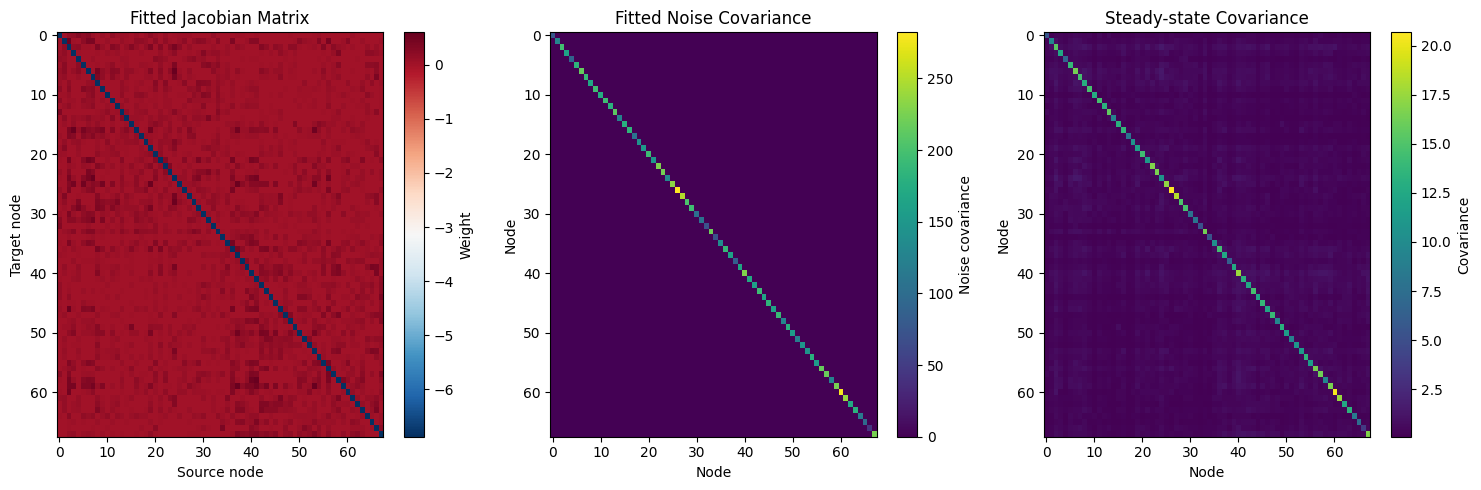

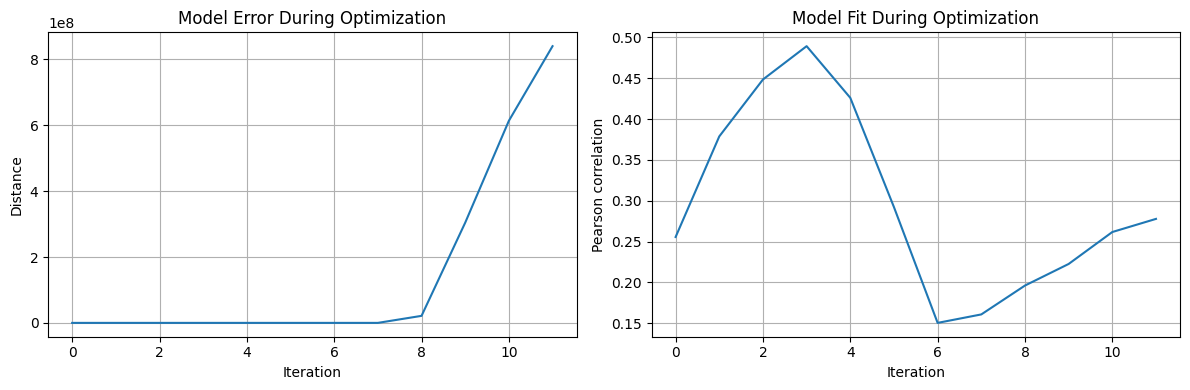

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
from utils import *

### Set up repositories, saving paths and global parameters

In [59]:
data_path = "D:\\Cogmaster\\M2\\stage\\data\\adEx_MF_baseline_and_psilo"
reduced_gk_query = "g_K_e_7"
baseline_gk_query = "g_K_e_8"
bold_filename = "bold.npy"
temporal_avg_filename = "temporal_average.npy"

situations = ['simulated_adex_BOLD', 'simulated_adex_FR']

In [109]:
res_dir = 'D:\\Cogmaster\\M2\\stage\\results' # results
presentation_figs_dir = 'C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\figs\\MF_AdEx_firing_rates_multiseeds'
os.makedirs(presentation_figs_dir, exist_ok=True)
graph_format = 'png' # graph formatting

In [87]:
list_directory = os.listdir(data_path)
reduced_gk_folders = [k for k in list_directory if baseline_gk_query in k]
baseline_gk_folders = [k for k in list_directory if reduced_gk_query in k]
assert len(reduced_gk_folders) == len(baseline_gk_folders), "Expected same number of folders for reduced and baseline gK conditions"

nb_seeds = len(reduced_gk_folders)
print(f"Found {nb_seeds} seeds for each condition")

Found 15 seeds for each condition


In [62]:
# Load arbitrary file to get time points and regions
bold_temp = np.load(os.path.join(data_path, list_directory[0], bold_filename))
temporal_average_temp = np.load(os.path.join(data_path, list_directory[0], temporal_avg_filename))
n_timepoints_bold, n_regions = bold_temp.shape[0], bold_temp.shape[-1]
n_timepoints_temporal_avg = temporal_average_temp.shape[0]

In [88]:
# Set cut transient 
cut_transient_fr = 20_000
cut_transient_bold = 10

In [96]:
# Set number of subjects and number of conditions
n_sub = nb_seeds
conds = ['baseline', 'reduced gK']
n_cond = len(conds) # number of conditions
n_tau = 2 # number of lags (0 and 1) for Q matrices

In [90]:
# Load arbitrary file to get time points and regions
bold_temp = np.load(os.path.join(data_path, list_directory[0], bold_filename))
temporal_average_temp = np.load(os.path.join(data_path, list_directory[0], temporal_avg_filename))
n_timepoints_bold, n_regions = bold_temp.shape[0], bold_temp.shape[-1]
n_timepoints_temporal_avg = temporal_average_temp.shape[0]
print(f"BOLD time points: {n_timepoints_bold}. Firing rate time points: {n_timepoints_temporal_avg}. Regions: {n_regions}")
# Initialize array to hold all BOLD data
bold_data = np.zeros((nb_seeds, n_timepoints_bold-cut_transient_bold, n_regions, n_cond))
temporal_avg_data = np.zeros((nb_seeds, n_timepoints_temporal_avg-cut_transient_fr, n_regions, n_cond))

BOLD time points: 175. Firing rate time points: 350000. Regions: 68


In [91]:
def load_and_process(data_path, folder_name, file_name, cut_transient):    
    """Load and process BOLD and temporal average data for a given folder name (seed)"""
    # Load bold or temporal average for a given seed
    signal_array = np.load(os.path.join(data_path, folder_name, file_name))
    n_timepoints, _, n_regions = signal_array.shape
    # Reshape from (time_points, 1, regions) to (time_points, regions)
    signal_array = signal_array.reshape(n_timepoints, n_regions)
    # Cut initial transient
    signal_array = signal_array[cut_transient:, :]
    # Z-score signal
    signal_array = z_score_per_region(signal_array)

    return signal_array

In [92]:
# Load all data for baseline gK condition
for idx, folder_name in enumerate(baseline_gk_folders):
    cond_temp = 0 # baseline condition
    # Store processed BOLD data for a given seed
    bold_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, bold_filename, cut_transient_bold)
    # Store processed temporal average data for a given seed
    temporal_avg_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, temporal_avg_filename, cut_transient_fr)

# Load all data for reduced gK condition
for idx, folder_name in enumerate(reduced_gk_folders):
    cond_temp = 1 # perturbed condition
    # Store processed BOLD data for a given seed
    bold_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, bold_filename, cut_transient_bold)
    # Store processed temporal average data for a given seed
    temporal_avg_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, temporal_avg_filename, cut_transient_fr)

print("BOLD array shape:", bold_data.shape)
print("Temporal average array shape:", temporal_avg_data.shape)

BOLD array shape: (15, 165, 68, 2)
Temporal average array shape: (15, 330000, 68, 2)


In [95]:
temporal_avg_data.shape

(15, 330000, 68, 2)

In [103]:
Q_data_fr = np.zeros((n_tau, n_sub, n_regions, n_regions, n_cond))
Q_data_bold = np.zeros((n_tau, n_sub, n_regions, n_regions, n_cond))

In [104]:
for sub in range(n_sub):
    for cond in range(n_cond):
        Q_data_temp = lagged_fc_matrices(temporal_avg_data[sub, :, :, cond], n_tau=2, diag_zero=False, z_score=True)
        Q_data_fr[:, sub, :, :, cond] = Q_data_temp

        Q_data_temp = lagged_fc_matrices(bold_data[sub, :, :, cond], n_tau=2, diag_zero=False, z_score=True)
        Q_data_bold[:, sub, :, :, cond] = Q_data_temp

print("Q_data_fr shape (n_tau, n_sub, n_regions, n_regions, n_cond):", Q_data_fr.shape)
print("Q_data_bold shape (n_tau, n_sub, n_regions, n_regions, n_cond):", Q_data_bold.shape)


Q_data_fr shape (n_tau, n_sub, n_regions, n_regions, n_cond): (2, 15, 68, 68, 2)
Q_data_bold shape (n_tau, n_sub, n_regions, n_regions, n_cond): (2, 15, 68, 68, 2)


In [106]:
# create topological mask for AAL90
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([n_regions,n_regions],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(n_regions):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,n_regions-1-i] = True # additional interhemispherical connections
print('network size:', n_regions)
print('EC density:', mask_EC.sum()/float(n_regions*(n_regions-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(n_regions,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


In [ ]:
# Mou fitting
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma
min_iter = 20
verbose=True

for situation_idx in range(len(situations)):
    Q_data = Q_data_bold if situations[situation_idx] == 'simulated_adex_BOLD' else Q_data_fr
    # Set and make directory to save results for current situation
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
    os.makedirs(res_dir_situation, exist_ok=True)
    # Run MOU fitting for current situation
    run_MOU_fitting(n_sub, n_cond, Q_data, n_regions, situations, situation_idx, mask_Sigma, min_iter,
                    presentation_figs_dir, graph_format, conds, 
                    res_dir = res_dir_situation, coef_S=None, coef_E=None, verbose=False)

In [112]:
import pandas as pd
import seaborn as sb 

In [117]:
def plot_mod_diag(array_mod, n_sub, n_cond, conds, 
                   cols, y_min, y_max, plot_ylabel, file_name, graph_format, res_dir):
    """Plot model array (e.g. error) as violin plot with swarmplot overlay"""
    array_mod_tmp = dict()
    array_mod_tmp['sum EC'] = array_mod.flatten()
    array_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
    array_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

    array_mod_df = pd.DataFrame(array_mod_tmp)

    if y_min is None:
        y_min = array_mod_df['sum EC'].min() * 0.9
    if y_max is None:
        y_max = array_mod_df['sum EC'].max() * 1.1

    plt.figure()
    sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
    sb.swarmplot(data=array_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
    plt.axis(ymin=y_min, ymax=y_max)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Condition',fontsize=16)
    plt.ylabel(plot_ylabel,fontsize=16)

    plt.tight_layout()
    plt.savefig(os.path.join(res_dir,file_name), format=graph_format)
    
def plot_mod_matrix(mod_matrix, mod_matrix_name, res_dir, graph_format):
    plt.figure(figsize=(5,4))
    #plt.imshow(np.maximum(mod_matrix[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
    plt.imshow(mod_matrix[0,0,:,:], cmap='Reds')   
    plt.colorbar()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Target ROI index', fontsize=16)
    plt.ylabel('Source ROI index', fontsize=16)
    plt.title(mod_matrix_name, fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(res_dir,f"{mod_matrix_name}_mod.{graph_format}"), format=graph_format)

Saving results for situation: simulated_adex_BOLD in directory: D:\Cogmaster\M2\stage\results
err_mod shape: (15, 2)
fit_mod shape: (15, 2)
J_mod shape: (15, 2, 68, 68)
Sigma_mod shape: (15, 2, 68, 68)


C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: UserWarning: The palette list has more values (4) than need

Saving results for situation: simulated_adex_FR in directory: D:\Cogmaster\M2\stage\results
err_mod shape: (15, 2)
fit_mod shape: (15, 2)
J_mod shape: (15, 2, 68, 68)
Sigma_mod shape: (15, 2, 68, 68)


C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\3882818741.py:17: UserWarning: The palette list has more values (4) than need

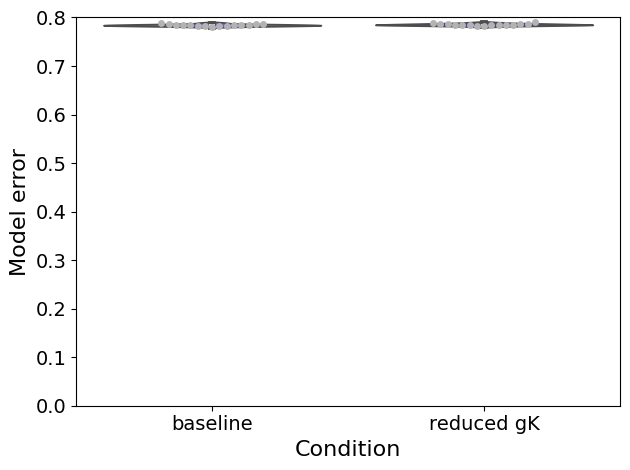

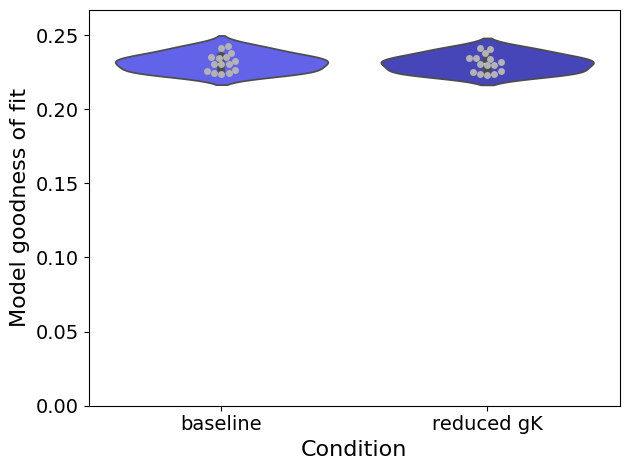

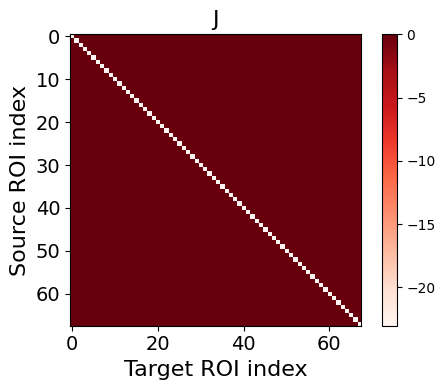

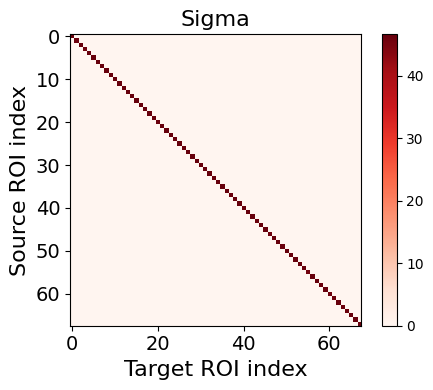

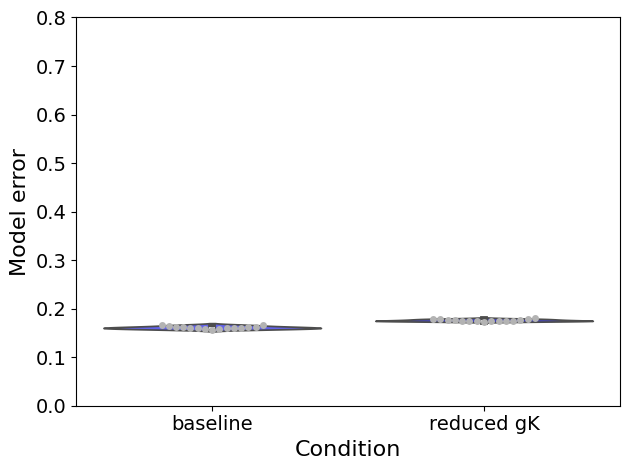

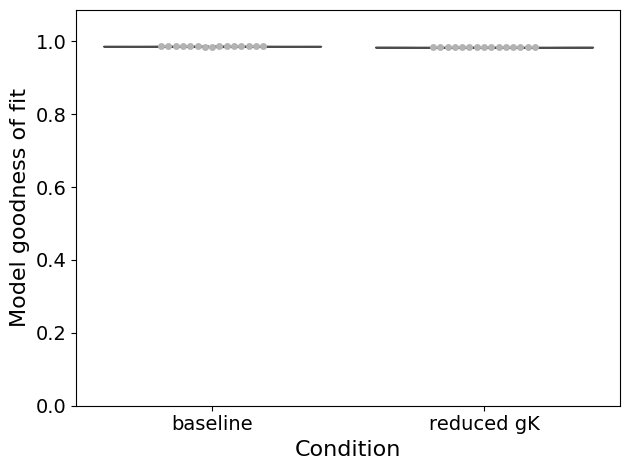

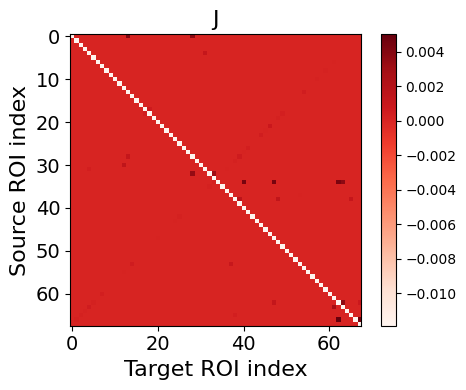

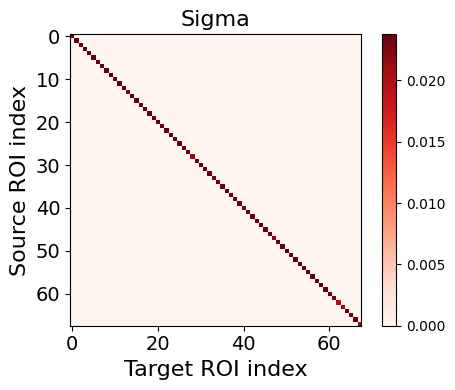

In [118]:
mask_diag = np.eye(n_regions, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

for situation_idx in range(len(situations)):
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
    print(f"Saving results for situation: {situations[situation_idx]} in directory: {res_dir}")
    err_mod = np.load(os.path.join(res_dir_situation, 'err_mod.npy'))
    print("err_mod shape:", err_mod.shape)
    fit_mod = np.load(os.path.join(res_dir_situation, 'fit_mod.npy'))
    print("fit_mod shape:", fit_mod.shape)
    J_mod = np.load(os.path.join(res_dir_situation, 'J_mod.npy'))
    print("J_mod shape:", J_mod.shape)
    Sigma_mod = np.load(os.path.join(res_dir_situation, 'Sigma_mod.npy'))
    print("Sigma_mod shape:", Sigma_mod.shape)

    # Model error
    plot_mod_diag(array_mod=err_mod, n_sub=n_sub, n_cond=n_cond, 
                   conds=conds, cols=cols, y_min=0, y_max = 0.8, 
                   plot_ylabel='Model error', 
                   file_name=f"model_fit_error.{graph_format}", 
                   graph_format=graph_format, res_dir=res_dir_situation)

    # Pearson correlation
    plot_mod_diag(array_mod=fit_mod, n_sub=n_sub, n_cond=n_cond, 
                   conds=conds, cols=cols, y_min=0, y_max = None, 
                   plot_ylabel='Model goodness of fit', 
                   file_name=f"model_goodness_fit.{graph_format}", 
                   graph_format=graph_format, res_dir=res_dir_situation)
    
    # J matrix 
    plot_mod_matrix(mod_matrix=J_mod, mod_matrix_name="J", res_dir=res_dir_situation, 
                    graph_format=graph_format)
    
    # Sigma matrix
    plot_mod_matrix(mod_matrix=Sigma_mod, mod_matrix_name="Sigma", res_dir=res_dir_situation, 
                    graph_format=graph_format)

In [125]:
from scipy import stats

In [124]:
EPR_df

,sleep stage,EPR
0,baseline,-0.0
1,reduced gK,-0.0
2,baseline,-0.0
3,reduced gK,-0.0
4,baseline,-0.0
5,reduced gK,-0.0
6,baseline,-0.0
7,reduced gK,-0.0
8,baseline,-0.0
9,reduced gK,-0.0


should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0


C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\2326622915.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=data,


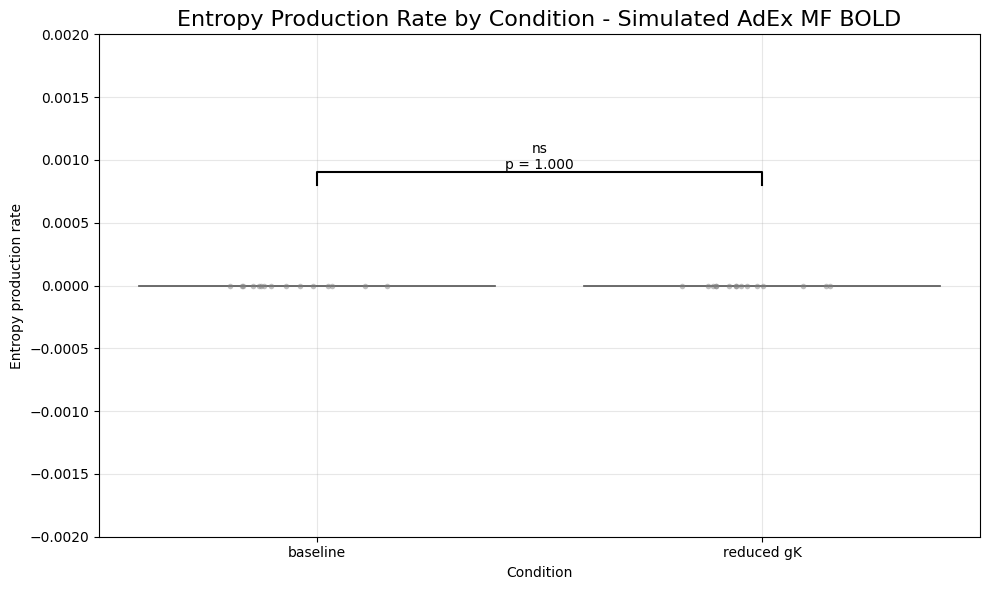


Statistical Test Results:
Mann-Whitney U test statistic: 112.5
p-value: 1.0
should be close to zero: 3.122502256758253e-17
should be close to zero: 4.85722573273506e-17
should be close to zero: 2.42861286636753e-17
should be close to zero: 5.204170427930421e-17
should be close to zero: 1.0408340855860843e-17
should be close to zero: 9.71445146547012e-17
should be close to zero: 5.204170427930421e-17
should be close to zero: 1.3877787807814457e-16
should be close to zero: 1.3877787807814457e-17
should be close to zero: 9.71445146547012e-17
should be close to zero: 4.163336342344337e-17
should be close to zero: 4.85722573273506e-17
should be close to zero: 2.7755575615628914e-17
should be close to zero: 5.898059818321144e-17
should be close to zero: 2.0816681711721685e-17
should be close to zero: 8.673617379884035e-17
should be close to zero: 2.0816681711721685e-17
should be close to zero: 3.469446951953614e-17
should be close to zero: 1.734723475976807e-17
should be close to zero: 1.21

C:\Users\Bruna\AppData\Local\Temp\ipykernel_1116\2326622915.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=data,


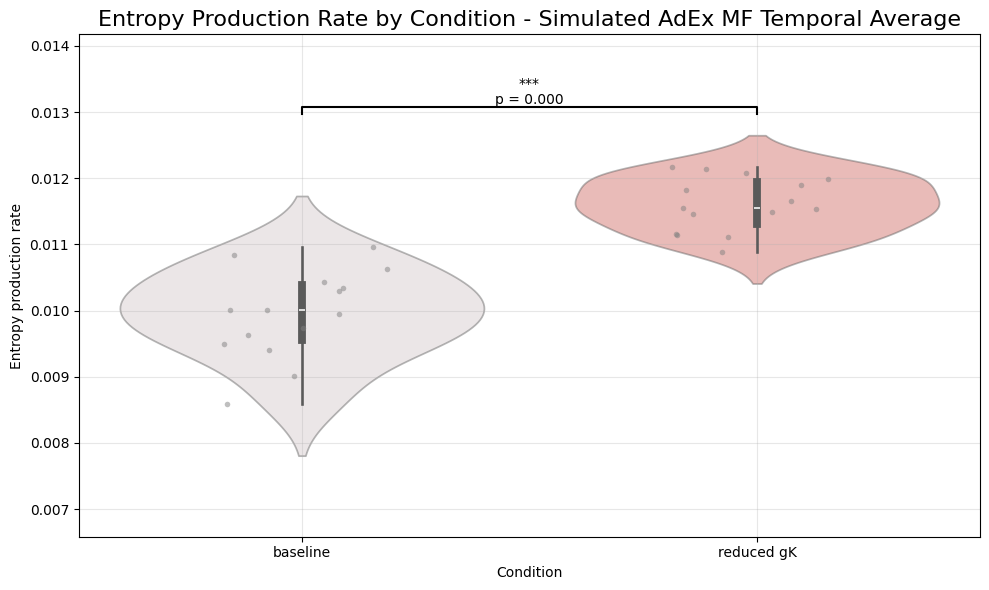


Statistical Test Results:
Mann-Whitney U test statistic: 1.0
p-value: 4.143220097537536e-06


In [148]:
mask_diag = np.eye(n_regions, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

situations_title_dict = { 'simulated_adex_BOLD': 'Simulated AdEx MF BOLD', 'simulated_adex_FR': 'Simulated AdEx MF Temporal Average' }

for situation_idx in range(len(situations)):
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
       
    J_mod = np.load(os.path.join(res_dir_situation, 'J_mod.npy'))
    Sigma_mod = np.load(os.path.join(res_dir_situation, 'Sigma_mod.npy'))
    FC0_mod = np.load(os.path.join(res_dir_situation, 'FC0_mod.npy'))

    # transpose to Saclay's framework
    EPR = np.zeros([n_sub,n_cond])
    Q_indiv = np.zeros([n_sub,n_cond,n_regions,n_regions])

    for i_sub in range(n_sub):
        for i_cond in range(n_cond):

            try:
                B = np.copy(-J_mod[i_sub,i_cond,:,:].T) # B=-J
                D = np.copy(0.5 * Sigma_mod[i_sub,i_cond,:,:]) # D=1/2 * Sigma
                S = np.copy(FC0_mod[i_sub,i_cond,:,:])
                
                Q = np.dot(B, S) - D
                Q_indiv[i_sub,i_cond,:,:] = Q
                
                # sanity check
                if True:
                    print('should be close to zero:', np.abs(np.dot(B,S) + np.dot(S,B.T) -2*D).max())
                
                # formula from Godreche Luck
                Dinv = np.linalg.pinv(D)
                Sinv = np.linalg.pinv(S)
                
                entropy_prod_rate = -np.trace(np.dot(np.dot(np.dot(Sinv, Q), Dinv), Q))  #-tr(S^(-1)*Q*D^(-1)*Q)
                EPR[i_sub,i_cond] = entropy_prod_rate

            except:
                print('problem with subject/cond:', i_sub, i_cond)
        

    np.save(os.path.join(res_dir_situation,'EPR.npy'),EPR)

    # Turn into dataframe for plotting
    EPR_tmp = dict()
    EPR_tmp['sleep stage'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()
    EPR_tmp['EPR'] = EPR.flatten()

    EPR_df = pd.DataFrame(EPR_tmp)

    #EPR_df=EPR_df.drop(index=13)

    # Create sample data (replace with your actual data)
    data = pd.DataFrame({
        'Condition': [conds[0]]*nb_seeds + [conds[1]]*nb_seeds,
        'Entropy_production_rate': np.concatenate([
            EPR_df[EPR_df['sleep stage'] == conds[0]]['EPR'].tolist(),
            EPR_df[EPR_df['sleep stage'] == conds[1]]['EPR'].tolist()
        ])
    })

    # Perform statistical test
    ctr_data = data[data['Condition'] == conds[0]]['Entropy_production_rate']
    scz_data = data[data['Condition'] == conds[1]]['Entropy_production_rate']

    # Perform Mann-Whitney U test (non-parametric test for independent samples)
    statistic, p_value = stats.mannwhitneyu(ctr_data, scz_data, alternative='two-sided')

    # Colors 
    palette = {conds[0]: '#D4C6C9', conds[1]: '#E1544C'}

    # Create the figure
    plt.figure(figsize=(10, 6))

    # Create violin plot
    sb.violinplot(data=data, 
                x='Condition', 
                y='Entropy_production_rate',
                palette = palette,
                alpha=0.44)

    # Add strip plot (individual points)
    sb.stripplot(data=data,
                x='Condition',
                y='Entropy_production_rate',
                color='gray',
                alpha=0.5,
                jitter=0.2,
                size=4)

    # Add significance bar
    def add_stat_annotation(p_value):
        # Define the significance level markers
        if p_value < 0.001:
            star_string = '***'
        elif p_value < 0.01:
            star_string = '**'
        elif p_value < 0.05:
            star_string = '*'
        else:
            star_string = 'ns'
        
        # Get y coordinates for the bar
        y_max = data['Entropy_production_rate'].max()
        bar_height = y_max + 0.0008
        
        # Plot the significance bar
        x1, x2 = 0, 1  # x-coordinates for CTR and SCZ
        bar_height_diff = 0.0001
        
        plt.plot([x1, x1, x2, x2], 
                [bar_height, bar_height + bar_height_diff, bar_height + bar_height_diff, bar_height],
                'k-', linewidth=1.5)
        
        # Add star annotation
        plt.text((x1 + x2) * 0.5, bar_height + bar_height_diff,
                f'{star_string}\np = {p_value:.3f}',
                ha='center', va='bottom')

    # Add the significance annotation
    add_stat_annotation(p_value)

    ymax = data['Entropy_production_rate'].max()
    ymin = data['Entropy_production_rate'].min()

    # Customize the plot
    plt.title(f'Entropy Production Rate by Condition - {situations_title_dict[situations[situation_idx]]}', fontsize=16)
    plt.xlabel('Condition')
    plt.ylabel('Entropy production rate')
    plt.ylim(ymin-0.002, ymax+0.002)  # Adjust the upper limit if needed to show the significance bar
    plt.grid(True, alpha=0.3)

    # Adjust layout
    plt.tight_layout()

    plt.savefig(os.path.join(res_dir_situation,f'entropy_prod_rate_statbar.{graph_format}'), 
                format=graph_format, dpi=300)
    plt.show()
    plt.close()

    # Print statistical test results
    print(f'\nStatistical Test Results:')
    print(f'Mann-Whitney U test statistic: {statistic}')
    print(f'p-value: {p_value}')
        